# Surface Eikonal equation on a 3-D coil tube

**PDE:** Surface eikonal — geodesic distance on a helical tube

$$|\nabla_S u|^2 = 1, \qquad u\big|_{\partial\Omega} = 0$$

where the **surface gradient** projects the 3-D gradient onto the tangent plane:

$$\nabla_S u \;=\; \nabla u \;-\; (\mathbf{n}\cdot\nabla u)\,\mathbf{n}$$

and $\mathbf{n}$ is the outward unit normal to the tube surface.

**Domain:** 3-D helical coil tube  
**BC:** $u = 0$ at the start (inlet) rim of the coil  
**Solution:** geodesic arc-length distance measured along the tube surface


## 1. Imports & environment

In [1]:
import pinns
import jax.numpy as jnp
import numpy as np

# Coil geometry — must match pinns.meshes.coil_tube() call below
COIL_RADIUS = 1.0   # R
TUBE_RADIUS  = 0.17  # r
PITCH        = 0.4  # axial rise per turn
N_TURNS      = 3


## Mesh & domain

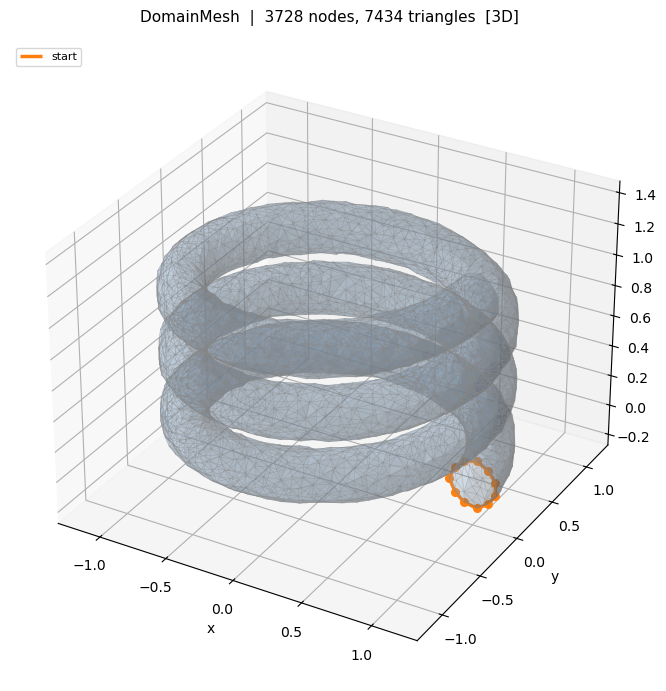

<Axes3D: xlabel='x', ylabel='y', zlabel='z'>

In [2]:
mesh = pinns.meshes.coil_tube(
    coil_radius=COIL_RADIUS,
    tube_radius=TUBE_RADIUS,
    n_turns=N_TURNS,
    pitch=PITCH,
    n_coil=120,
    mesh_size=0.15,
    open_ends=True,
)

domain = pinns.domain.DomainMesh(mesh)

# Boundary region: inlet rim (z near 0)
z_min = mesh[0][:, 2].min()
domain.add_boundary(lambda x: x[:, 2] < z_min + TUBE_RADIUS * 2, "start")

domain.plot(boundary="custom", backend="matplotlib")


## PDE — surface eikonal

The residual for the **strong-form** eikonal:

$$\mathcal{R}(u) = |\nabla_S u|^2 - 1 = 0$$

The **surface normal** $\mathbf{n}$ at each collocation point is available as
`params['normals_eikonal']`.  The `Trainer` precomputes it once when
sampling (via area-weighted vertex normal interpolation on the mesh) and stores
it in `fixed_params` — so it is a plain constant array inside the JIT kernel,
not recomputed every step.  After a `SchedulerResample` refresh the normals are
automatically recomputed for the new sample.


In [3]:
def eikonal_fn(x, u, params, derivative):
    """Surface eikonal residual: |∇_S u| - 1 = 0."""
    du_dx = derivative(u, x, 0, (0,)).ravel()
    du_dy = derivative(u, x, 0, (1,)).ravel()
    du_dz = derivative(u, x, 0, (2,)).ravel()
    grad_u = jnp.stack([du_dx, du_dy, du_dz], axis=1)  # (N, 3)

    n = params['domain']['normals']  # (N, 3)

    n_dot_grad = jnp.sum(n * grad_u, axis=1, keepdims=True)
    grad_S_u   = grad_u - n_dot_grad * n                    # (N, 3)

    norm_grad_S_u = jnp.sqrt(jnp.sum(grad_S_u ** 2, axis=1) + 1e-8)
    return norm_grad_S_u - 1.0

problem = pinns.ProblemStrong(domain=domain, output_names=["u"])
problem.add_inner(eikonal_fn, name="eikonal")

problem.add_dirichlet(0.0, name="start", region="start")

ProblemStrong(domain=DomainMesh, n_dims=3, n_outputs=1, inner=1, boundary=1, initial=0, params=[], trainable=[])

In [4]:
model = pinns.create_model(
    domain,
    output_dim=1,
    features=pinns.LaplacianFeatures(n_features=50),
    hidden_dims=[64,64,64],
)
print(model)

LaplacianFeatures: computing 51 Laplace eigenvectors for mesh with 3728 nodes (dropping constant mode 0) … done.
ModelBase(output_dim=1)
  [Normalize_0] Normalize(n_coord=3, n_context=0, context_scaled=False)
  [LaplacianFeatures_1] LaplacianFeatures(output_dim=50, mode='50 eigenvectors')
  [FNN_2] FNN(layer_sizes=[50, 64, 64, 64, 1])


In [5]:
## Build 40-point dataset with true geodesic distances from the inlet rim
# Geodesic distance is computed via Dijkstra on the mesh edge graph with
# Euclidean edge lengths as weights.  This gives the exact piecewise-linear
# geodesic distance from the inlet boundary to every vertex.

import scipy.sparse as sp_sparse
import scipy.sparse.csgraph as sp_graph

rng_data = np.random.default_rng(42)

verts = domain._vertices          # (n_nodes, 3)
faces = domain._faces             # (n_faces, 3)
n_nodes = len(verts)

# Build weighted adjacency matrix from mesh edges
rows, cols, data = [], [], []
for face in faces:
    for j in range(3):
        a, b = int(face[j]), int(face[(j + 1) % 3])
        d = float(np.linalg.norm(verts[a] - verts[b]))
        rows += [a, b]; cols += [b, a]; data += [d, d]
adj = sp_sparse.csr_matrix((data, (rows, cols)), shape=(n_nodes, n_nodes))

# Source nodes: inlet rim (same boundary as 'start' in the domain)
z_min_val = verts[:, 2].min()
source_mask = verts[:, 2] < z_min_val + TUBE_RADIUS * 2
source_nodes = np.where(source_mask)[0]

# Dijkstra geodesic distance from any source node (multi-source = min over all)
dist_matrix = sp_graph.shortest_path(adj, method='D',
                                     directed=False,
                                     indices=source_nodes)
geo_dist = dist_matrix.min(axis=0)   # (n_nodes,) distance from inlet

# Sample 40 random interior nodes (not on the source boundary) as data points
interior_mask = ~source_mask
interior_idx  = np.where(interior_mask)[0]
node_idx = rng_data.choice(interior_idx, size=40, replace=False)

x_data = verts[node_idx].astype(np.float32)   # (40, 3)
u_data = geo_dist[node_idx].astype(np.float32) # (40,) true geodesic distance

dataset = pinns.Dataset()
dataset.add_points(x_data, u_data, name="sparse_data", component=0)

print(f"Geodesic distance range: [{geo_dist.min():.3f}, {geo_dist.max():.3f}]")
print(f"Data points: {x_data.shape}, u range: [{u_data.min():.3f}, {u_data.max():.3f}]")


Geodesic distance range: [0.000, 24.512]
Data points: (40, 3), u range: [0.102, 23.144]


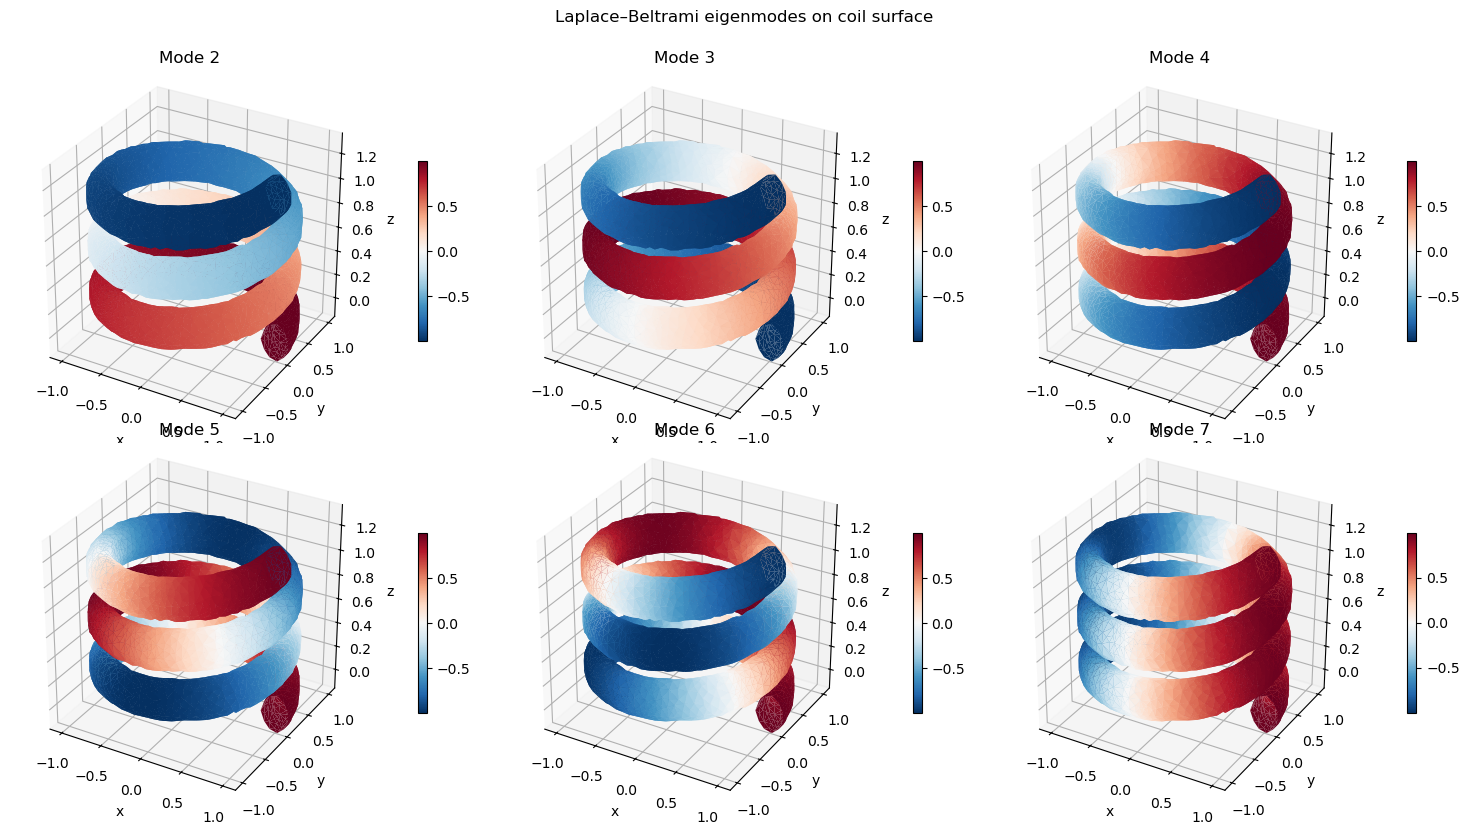

In [6]:

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Extract the LaplacianFeatures encoder from the model
enc = model._layers[1]   # layer 0 = Normalize, layer 1 = LaplacianFeatures
Phi = np.array(enc._Phi)          # (n_nodes, n_eig)  — mode 0 already removed
verts = domain._vertices          # (n_nodes, 3)
faces = domain._faces             # (n_faces, 3)

N_MODES = 6   # how many eigenmodes to display
ncols = N_MODES // 2
fig = plt.figure(figsize=(5 * ncols, 8))

for i in range(N_MODES):
    ax = fig.add_subplot(2, ncols, i + 1, projection="3d")

    vals = Phi[:, i]
    face_vals = vals[faces].mean(axis=1)
    v_min, v_max = face_vals.min(), face_vals.max()
    if v_min == v_max:
        v_max = v_min + 1.0
    cmap = cm.RdBu_r
    norm = mcolors.Normalize(vmin=v_min, vmax=v_max)
    facecolors = cmap(norm(face_vals))

    polys = verts[faces]
    coll = Poly3DCollection(polys, facecolors=facecolors, edgecolors='none', linewidths=0)
    ax.add_collection3d(coll)
    for dim, setter in enumerate([ax.set_xlim3d, ax.set_ylim3d, ax.set_zlim3d]):
        setter(verts[:, dim].min(), verts[:, dim].max())
    ax.set_title(f"Mode {i + 2}")
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.set_box_aspect([1, 1, 1])

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.1)

plt.suptitle("Laplace–Beltrami eigenmodes on coil surface", y=1.01)
plt.tight_layout()
plt.show()

## Training

Minimise $\mathcal{L} = \|\,|\nabla_S u_\theta|^2 - 1\,\|^2 + \lambda\|u_\theta|_{\partial\Omega}\|^2$


Starting training for 10000 epochs (JIT-compiled)...


/home/gatocor/Documentos/PINN/pinn_models/pinns/trainer/_plotting.py:1470: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


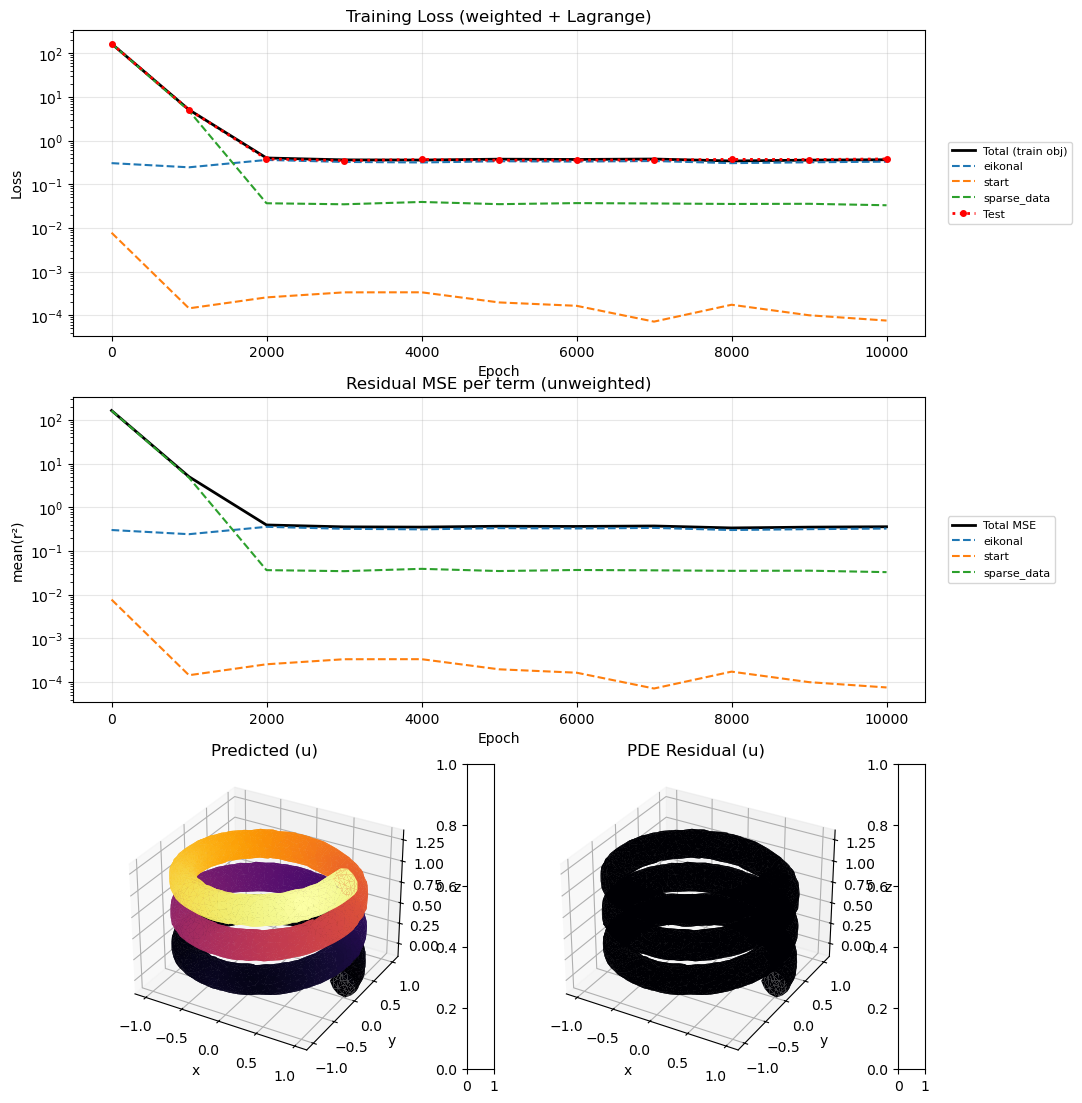

Epoch 0/10000 | Loss: 1.65e+02 | MSE: 1.65e+02 | Terms: [eikonal: 3.04e-01, start: 7.75e-03] | Data: [sparse_data: 1.64e+02] | Test Loss: 1.65e+02 | Time: 0.0s
Epoch 1000/10000 | Loss: 5.06e+00 | MSE: 5.04e+00 | Terms: [eikonal: 2.44e-01, start: 1.44e-04] | Data: [sparse_data: 4.80e+00] | Test Loss: 5.05e+00 | Time: 45.9s
Epoch 2000/10000 | Loss: 3.98e-01 | MSE: 3.96e-01 | Terms: [eikonal: 3.59e-01, start: 2.56e-04] | Data: [sparse_data: 3.66e-02] | Test Loss: 3.79e-01 | Time: 83.3s
Epoch 3000/10000 | Loss: 3.61e-01 | MSE: 3.58e-01 | Terms: [eikonal: 3.23e-01, start: 3.34e-04] | Data: [sparse_data: 3.47e-02] | Test Loss: 3.47e-01 | Time: 120.7s
Epoch 4000/10000 | Loss: 3.57e-01 | MSE: 3.54e-01 | Terms: [eikonal: 3.15e-01, start: 3.35e-04] | Data: [sparse_data: 3.92e-02] | Test Loss: 3.70e-01 | Time: 158.4s
Epoch 5000/10000 | Loss: 3.74e-01 | MSE: 3.70e-01 | Terms: [eikonal: 3.35e-01, start: 1.97e-04] | Data: [sparse_data: 3.49e-02] | Test Loss: 3.53e-01 | Time: 196.2s
Epoch 6000/10000 

In [7]:
trainer = pinns.Trainer(model, problem=problem, dataset=dataset)

trainer.compile(
    problem={
        "eikonal":  {"train": 1000, "test": 1000, "weight": 1.0},
        "start": {"train": 3, "test": 3, "weight": 1.0},
    },
    dataset={
        "sparse_data": {"train": 40, "test": 0, "weight": 1.0},
    },
    schedulers=[ 
        pinns.SchedulerResample(1)
    ],
    optimizer=pinns.SOAPOptimizer(),
    epochs=10000,
    print_each=1000,
)

trainer.train()